#1. 영상의 이진화

Mounted at /content/gdrive


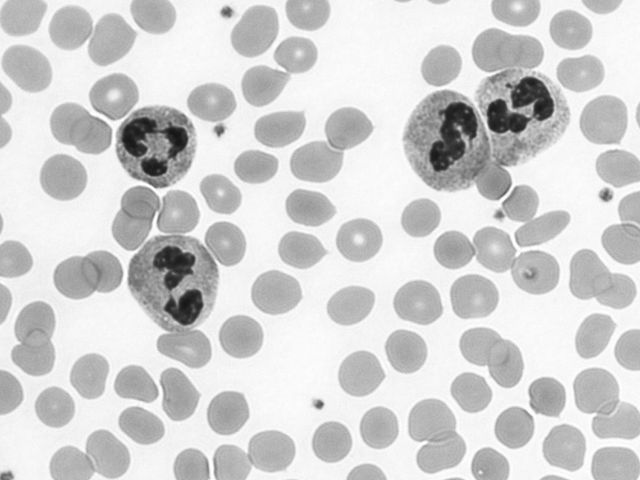

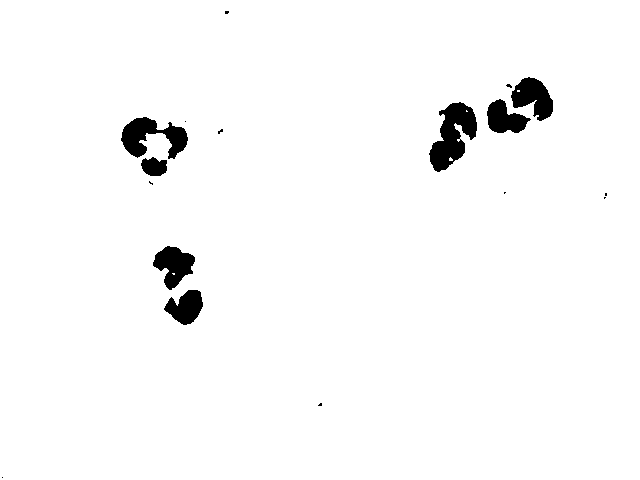

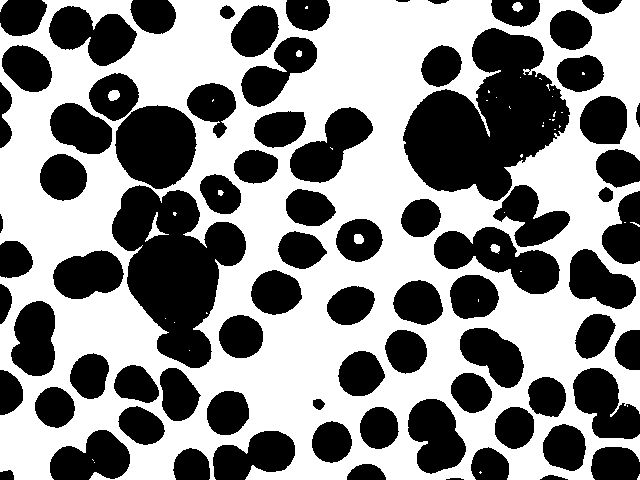

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

from google.colab.patches import cv2_imshow

import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/cells.png', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

_ , dst1 = cv2.threshold(src, 100, 255, cv2.THRESH_BINARY)
_ , dst2 = cv2.threshold(src, 210, 255, cv2.THRESH_BINARY)

cv2_imshow(src)
cv2_imshow(dst1)
cv2_imshow(dst2)

# cv2.waitKey()
# cv2.destroyAllWindows()


#2. 자동 이진화 Otsu 방법

otsu's threshold: 131.0


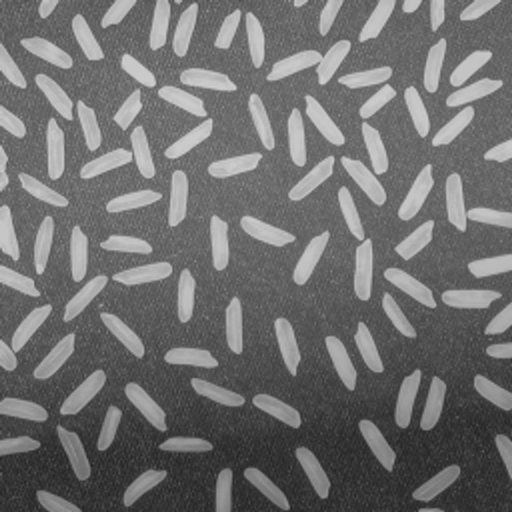

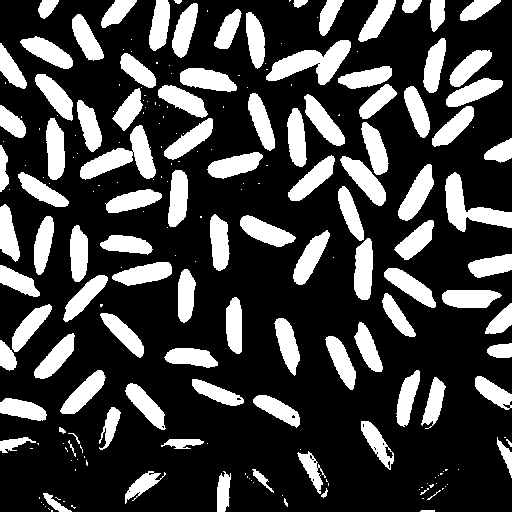

In [ ]:
import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/rice.png', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

th, dst = cv2.threshold(src, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)  # |는 or을 의미
print("otsu's threshold:", th)  # 131

cv2_imshow(src)
cv2_imshow(dst)
# cv2.waitKey()
# cv2.destroyAllWindows()


#3. 지역 이진화 : Otsu 적용

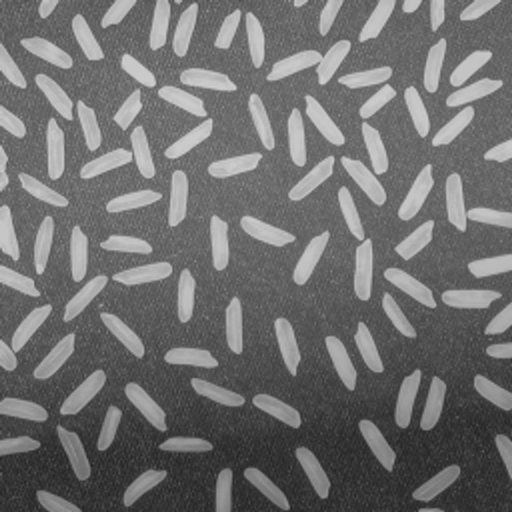

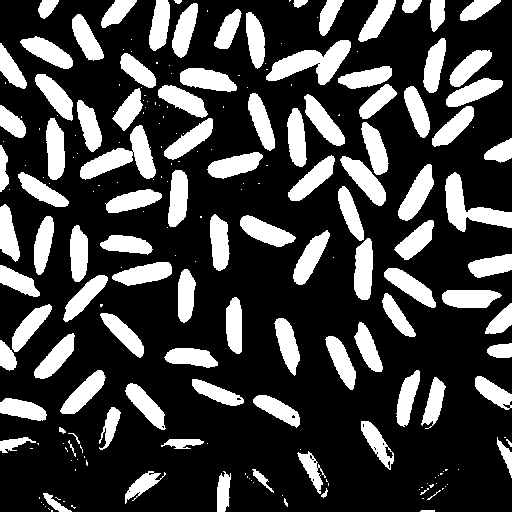

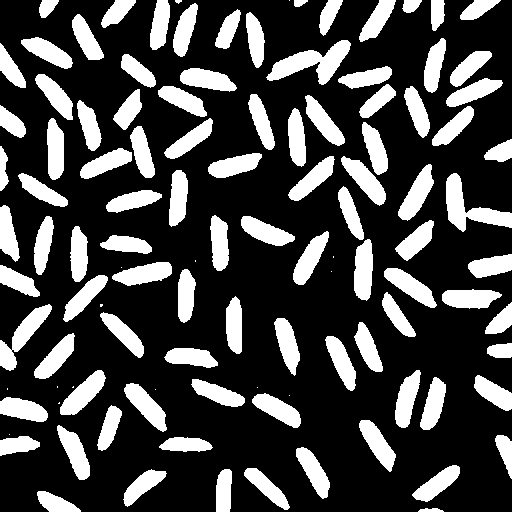

In [ ]:
import sys
import numpy as np
import cv2

# 입력 영상 불러오기
src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/rice.png', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

# 전역 이진화 by Otsu's method
_, dst1 = cv2.threshold(src, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

# 지역 이진화 by Otsu's method
dst2 = np.zeros(src.shape, np.uint8)

bw = src.shape[1] // 4  #정수 나눗셈 > 512/4 = 128
bh = src.shape[0] // 4

for y in range(4):
    for x in range(4):
        src_ = src[y*bh:(y+1)*bh, x*bw:(x+1)*bw]
        dst_ = dst2[y*bh:(y+1)*bh, x*bw:(x+1)*bw]
        cv2.threshold(src_, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU, dst_)

# 결과 출력
cv2_imshow(src)
cv2_imshow(dst1)
cv2_imshow(dst2)

# cv2.waitKey()
# cv2.destroyAllWindows()


#4. 지역 이진화 : 적응형 이진화

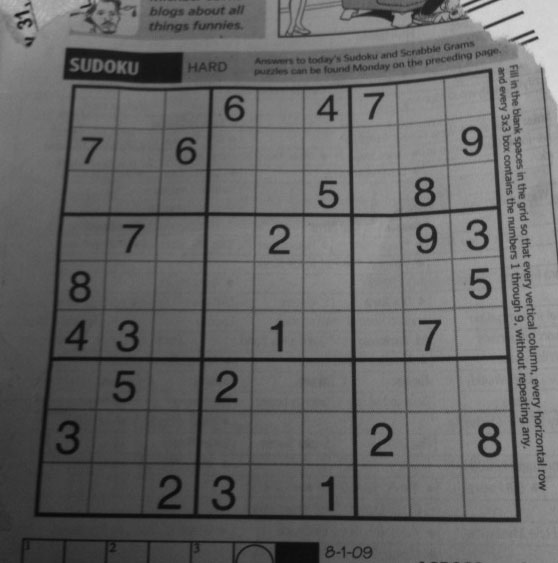

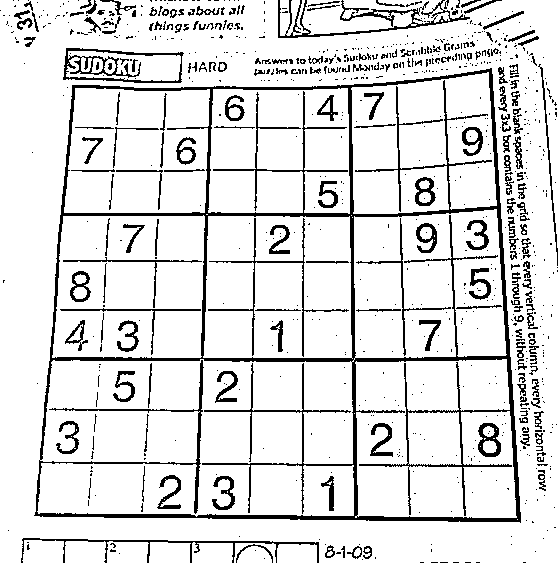

In [ ]:
import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/sudoku.jpg', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

# 블럭 크기 = 3
bsize = 7

dst = cv2.adaptiveThreshold(src, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY, bsize, 5)

cv2_imshow(src)
cv2_imshow(dst)

# cv2.waitKey()
# cv2.destroyAllWindows()


#5. 모폴로지 연산 : 침식과 팽창

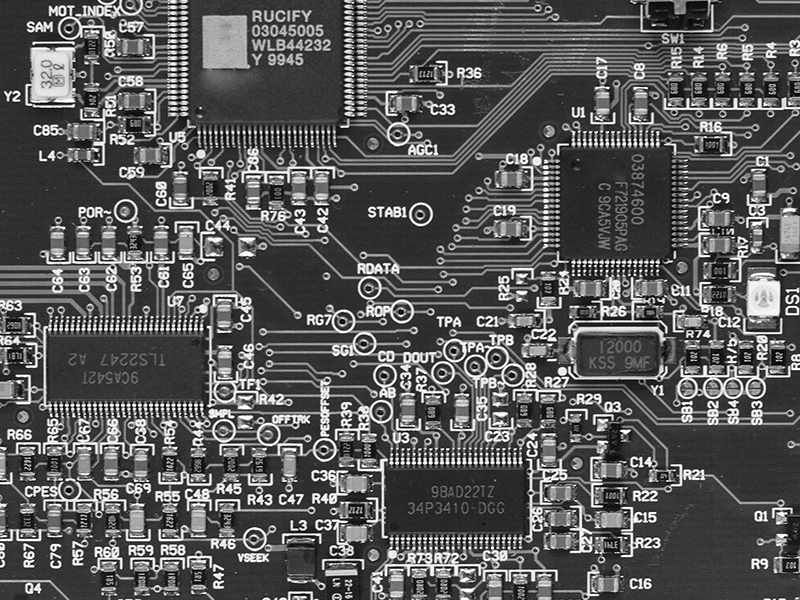

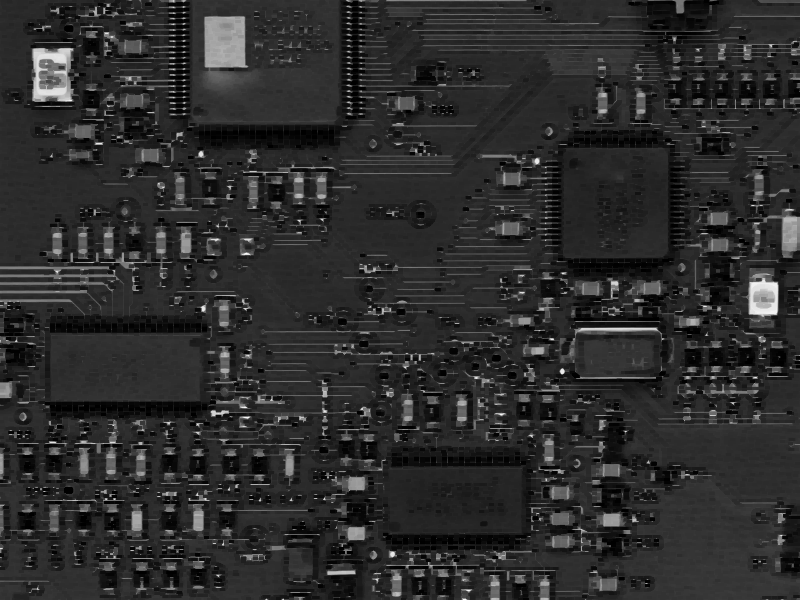

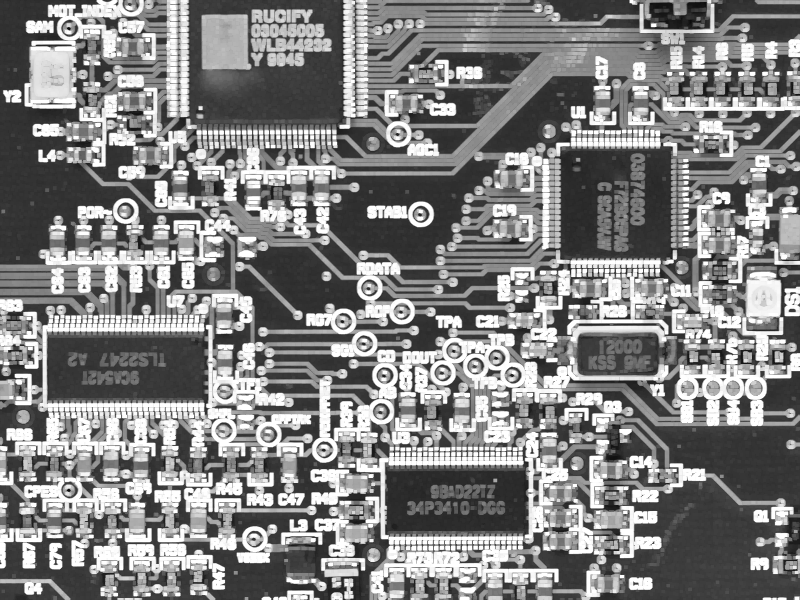

In [ ]:
import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/circuit.bmp', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

se = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3))
dst1 = cv2.erode(src, se)
dst2 = cv2.dilate(src, None)

cv2_imshow(src)
cv2_imshow(dst1)
cv2_imshow(dst2)

# cv2.waitKey()
# cv2.destroyAllWindows()

#6. 모폴로지 열기와 닫기 연산

cnt1: 113
cnt2: 99


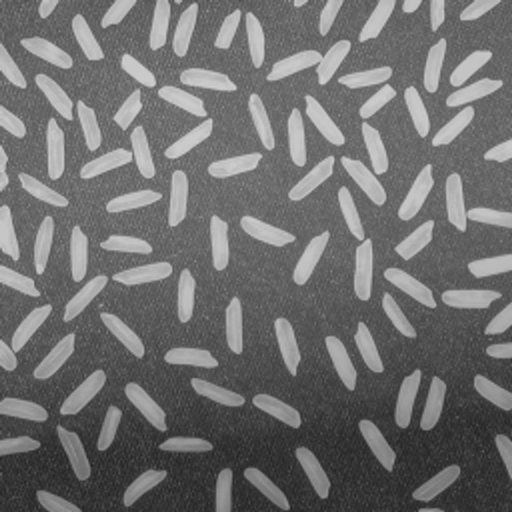

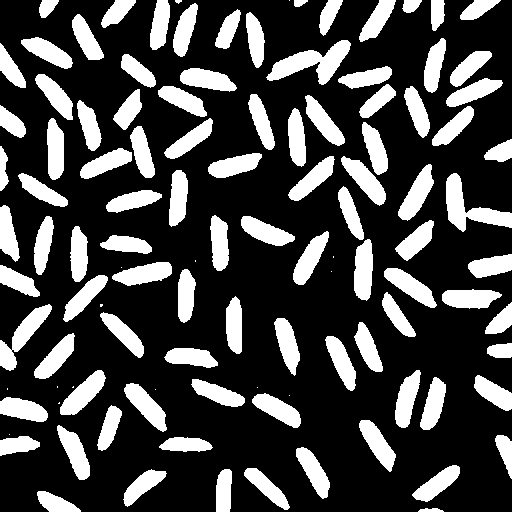

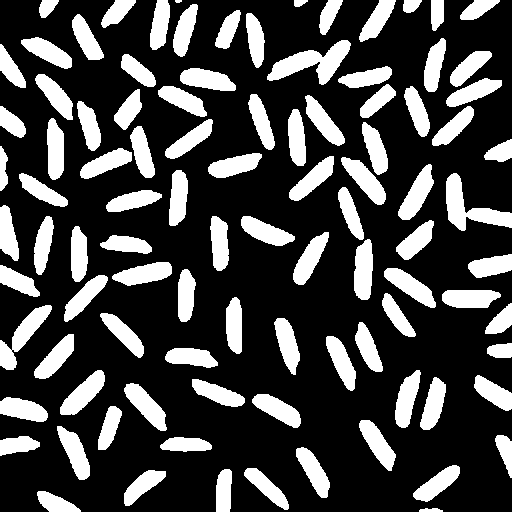

In [ ]:
import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/rice.png', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

# src 영상에 지역 이진화 수행 (local_th.py 참고)
dst1 = np.zeros(src.shape, np.uint8)

bw = src.shape[1] // 4
bh = src.shape[0] // 4

for y in range(4):
    for x in range(4):
        src_ = src[y*bh:(y+1)*bh, x*bw:(x+1)*bw]
        dst_ = dst1[y*bh:(y+1)*bh, x*bw:(x+1)*bw]
        cv2.threshold(src_, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU, dst_)

cnt1, _ = cv2.connectedComponents(dst1) #connectedComponents는 덩어리 개수를 새는 것
print('cnt1:', cnt1)

dst2 = cv2.morphologyEx(dst1, cv2.MORPH_OPEN, None) #open은 깎아내고 확장하는 것 > 쌀알이 아닌 작은 노이즈를 제거하는 과정
#dst2 = cv2.erode(dst1, None)
#dst2 = cv2.dilate(dst2, None)

cnt2, _ = cv2.connectedComponents(dst2)
print('cnt2:', cnt2)

cv2_imshow(src)
cv2_imshow(dst1)
cv2_imshow(dst2)

# cv2.waitKey()
# cv2.destroyAllWindows()

#7. 레이블링

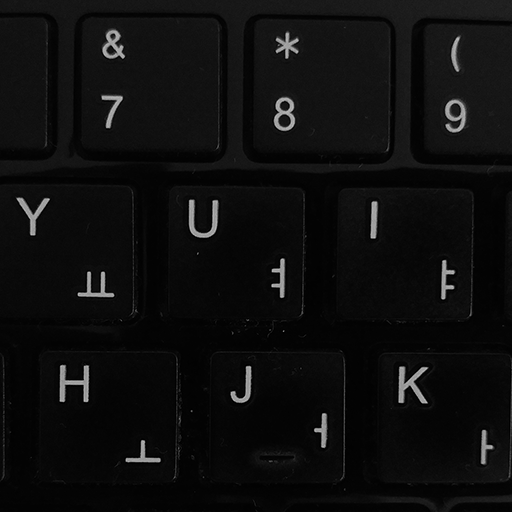

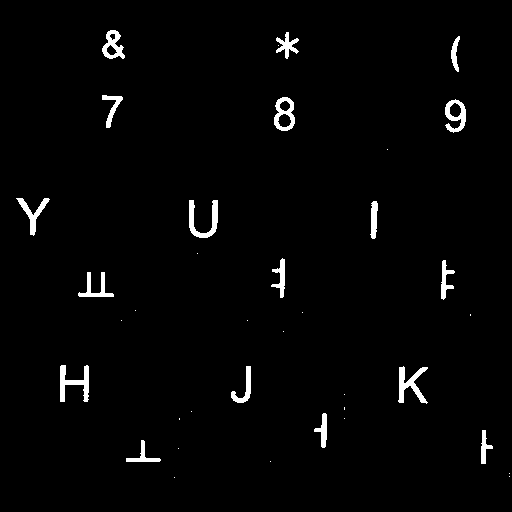

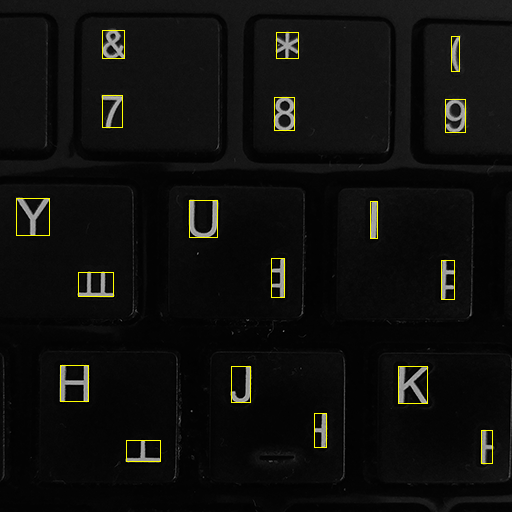

In [2]:
import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/keyboard.bmp', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

_, src_bin = cv2.threshold(src, 0, 255, cv2.THRESH_OTSU)

cnt, labels, stats, centroids = cv2.connectedComponentsWithStats(src_bin)

dst = cv2.cvtColor(src, cv2.COLOR_GRAY2BGR)

for i in range(1, cnt):
    (x, y, w, h, area) = stats[i]

    if area < 20:
        continue

    cv2.rectangle(dst, (x, y, w, h), (0, 255, 255))

cv2_imshow(src)
cv2_imshow(src_bin)
cv2_imshow(dst)

# cv2.waitKey()
# cv2.destroyAllWindows()

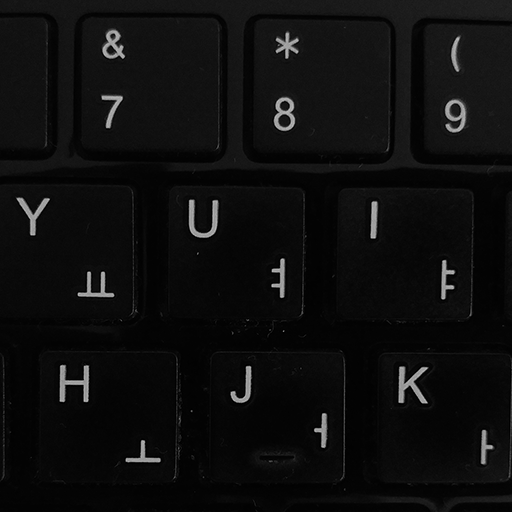

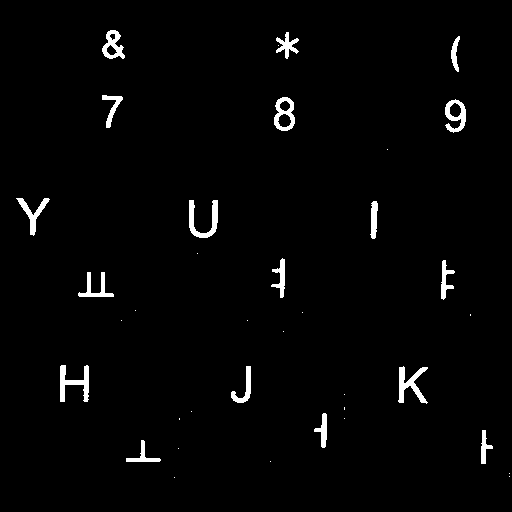

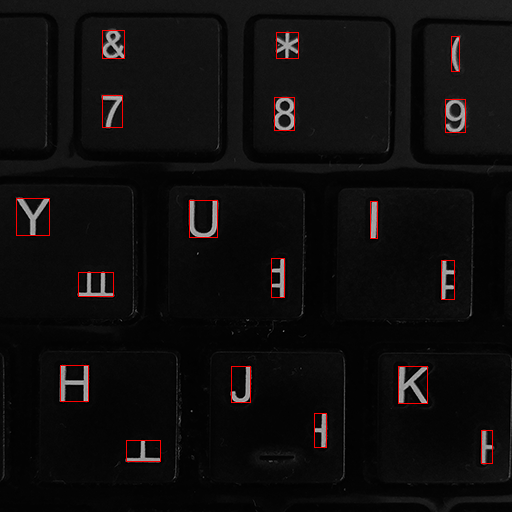

In [3]:
import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/keyboard.bmp', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

_, src_bin = cv2.threshold(src, 0, 255, cv2.THRESH_OTSU)

cnt, labels, stats, centroids = cv2.connectedComponentsWithStats(src_bin)

dst = cv2.cvtColor(src, cv2.COLOR_GRAY2BGR)

for i in range(1, cnt):
    (x, y, w, h, area) = stats[i]

    if area < 20:
        continue

    cv2.rectangle(dst, (x, y, w, h), (0, 0, 255))

cv2_imshow(src)
cv2_imshow(src_bin)
cv2_imshow(dst)

# cv2.waitKey()
# cv2.destroyAllWindows()

#8. 외곽선 검출

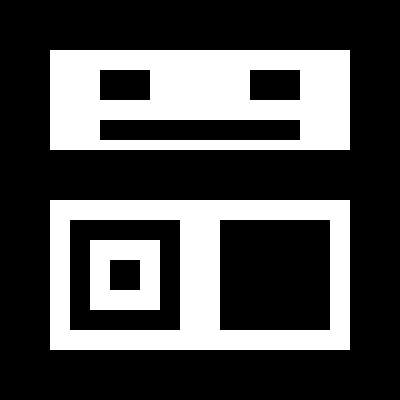

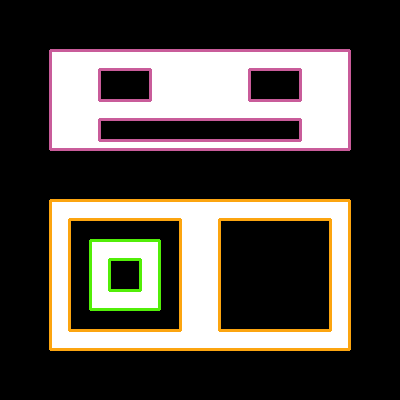

In [ ]:
import sys
import random
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/contours.bmp', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

contours, hier = cv2.findContours(src, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)

dst = cv2.cvtColor(src, cv2.COLOR_GRAY2BGR)

idx = 0
while idx >= 0:
    c = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    cv2.drawContours(dst, contours, idx, c, 2, cv2.LINE_8, hier)
    idx = hier[0, idx, 0]

cv2_imshow(src)
cv2_imshow(dst)

# cv2.waitKey()
# cv2.destroyAllWindows()


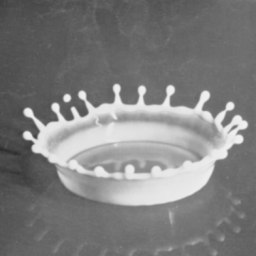

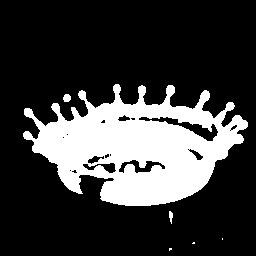

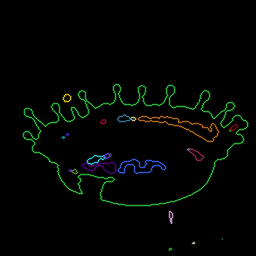

In [ ]:
import sys
import random
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/milkdrop.bmp', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

_, src_bin = cv2.threshold(src, 0, 255, cv2.THRESH_OTSU)

contours, _ = cv2.findContours(src_bin, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

h, w = src.shape[:2]
dst = np.zeros((h, w, 3), np.uint8)

for i in range(len(contours)):
    c = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) #외각선을 딸 때마다 랜덤한 색으로 검출
    cv2.drawContours(dst, contours, i, c, 1, cv2.LINE_AA)

cv2_imshow(src)
cv2_imshow(src_bin)
cv2_imshow(dst)

# cv2.waitKey()
# cv2.destroyAllWindows()

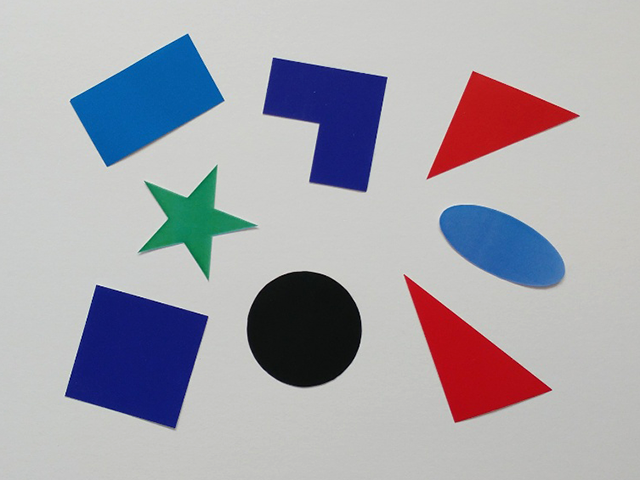

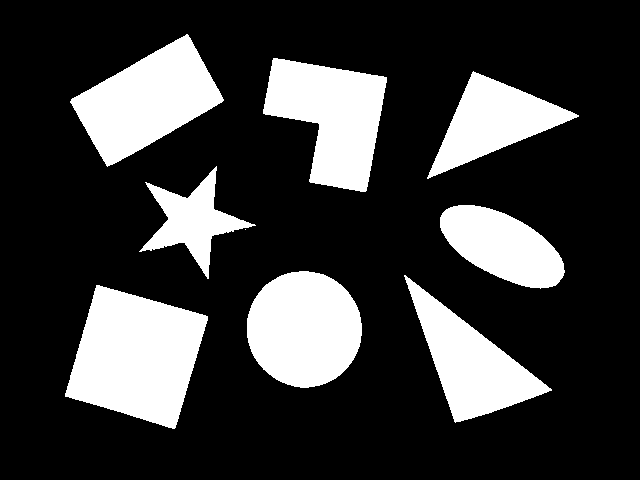

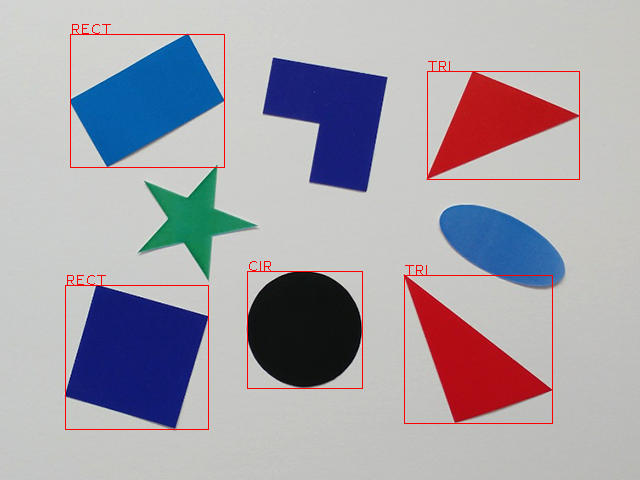

In [ ]:
import math
import cv2

def setLabel(img, pts, label):
    (x, y, w, h) = cv2.boundingRect(pts)
    pt1 = (x, y)
    pt2 = (x + w, y + h)
    cv2.rectangle(img, pt1, pt2, (0, 0, 255), 1)
    cv2.putText(img, label, pt1, cv2.FONT_HERSHEY_PLAIN, 1, (0, 0, 255))

def main():
    img = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/polygon.bmp', cv2.IMREAD_COLOR)

    if img is None:
        print('Image load failed!')
        return

    cv2_imshow(img) # 원본 영상 출력

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, img_bin = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

    cv2_imshow(img_bin) # 이진화 영상 출력

    contours, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    for pts in contours:
        if cv2.contourArea(pts) < 400:  #  너무 작으면 무시
            continue

        approx = cv2.approxPolyDP(pts, cv2.arcLength(pts, True)*0.02, True)

        vtc = len(approx)

        if vtc == 3:
            setLabel(img, pts, 'TRI')
        elif vtc == 4:
            setLabel(img, pts, 'RECT')
        else:
            length = cv2.arcLength(pts, True)
            area = cv2.contourArea(pts)
            ratio = 4. * math.pi * area / (length * length)

            if ratio > 0.85:
                setLabel(img, pts, 'CIR')

    cv2_imshow(img)

#    cv2.waitKey()
#    cv2.destroyAllWindows()

if __name__ == '__main__':
    main()